In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

In [ ]:
file_path = "/content/drive/MyDrive/dataset/network_latency_dataset.csv"

In [ ]:
df = pd.read_csv(file_path)

In [ ]:
df.isnull().sum()

,0
packet_size_bytes,0
latency_ms,0


In [ ]:
df.head()

,packet_size_bytes,latency_ms
0,1190,22.277951
1,924,19.690787
2,1358,23.590545
3,1194,32.330888
4,1159,27.806990


In [ ]:
x = df[['packet_size_bytes']]
y = df['latency_ms']

In [ ]:
x.shape

(5000, 1)

In [ ]:
y.shape

(5000,)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
print("R2 score:", r2_score(y_test, y_pred))

R2 score: 0.7309546714913746


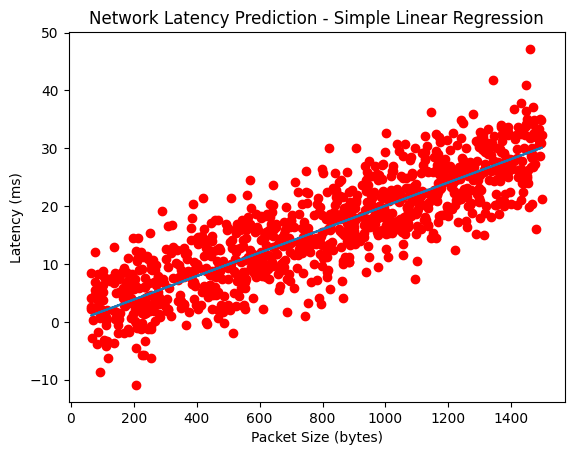

In [ ]:
plt.scatter(x_test, y_test, color="red")
plt.plot(x_test,y_pred)
plt.xlabel("Packet Size (bytes)")
plt.ylabel("Latency (ms)")
plt.title("Network Latency Prediction - Simple Linear Regression")
plt.show()

In [ ]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 0.02023742825411692
Intercept: -0.197255808452935


In [ ]:
import joblib

In [ ]:
joblib.dump(model, "network_latency_model.pkl")

['network_latency_model.pkl']

In [ ]:
import os

print(os.path.exists("network_latency_model.pkl"))

True


In [ ]:
loaded_model = joblib.load("network_latency_model.pkl")

# Test prediction
sample_packet_size = [[500]]  # 500 bytes
predicted_latency = loaded_model.predict(sample_packet_size)

print("Predicted Latency:", predicted_latency[0])

Predicted Latency: 9.921458318605525


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import os
print(os.getcwd())

/content
